<a href="https://colab.research.google.com/github/sanit15/pytorch/blob/main/02_pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.2 Neural Network classification with PyTorch

Classification is a problem of predictionf whether something is one thing or another (can be multiple things as the options)

In [1]:
## 1. Make some data
import sklearn
from sklearn.datasets import make_circles

# Make 100 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples, noise = 0.03, random_state = 42)

In [2]:
len(X), len(y)

(1000, 1000)

In [3]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 dsamples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 dsamples of y: [1 1 1 1 0]


In [4]:
# Make DataFrame of circles ata
import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})
circles.head(10)

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


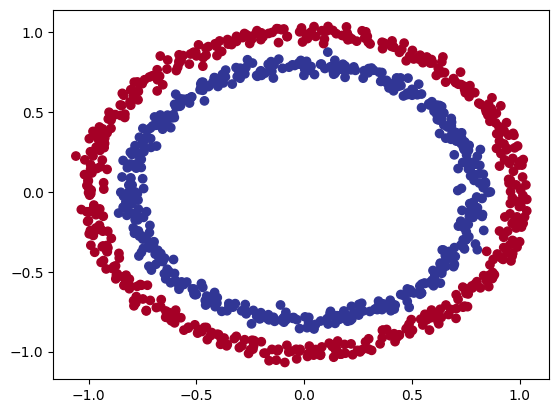

In [5]:
# visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y =X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)

**Note:** The data we're working out with is often referred to as a toy dataset, a dataset that is smakk enough to experniment but still sizeable enough to practise the fundamental

## 1.1 Check input and output shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# VIew the firat sample of featires and labels
X_sample = X[0]
y_sample = y[0]
print(f"Sample featires: {X_sample}, Sample label: {y_sample}")
print(f"Shape for one sample of features: {X_sample.shape}, and sthe same for ylabel: {y_sample.shape}")

Sample featires: [0.75424625 0.23148074], Sample label: 1
Shape for one sample of features: (2,), and sthe same for ylabel: ()


### 1.2 Turn data into tensors and create train and test split

In [8]:
import torch
torch.__version__

'2.11.0+cu128'

In [9]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [10]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
#split data into training and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2, # 0.2 = 20% of data will be test
                                                    random_state = 42)

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Lets build a model to classify our data

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelarator if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test losp

In [13]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
X_train.shape

torch.Size([800, 2])

In [15]:
# 1. construct a model
class CircularModelv1(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. Create 2 nn.Linear layes capable of handeling the shapes of our data
    self.layer_1 = nn.Linear(in_features = 2,
                             out_features = 5)
    self.layer_2 = nn.Linear(in_features = 5,
                             out_features = 1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> y

# 4. intantiate an instanse of our model class and send it to the target device
model_0 = CircularModelv1().to(device)
model_0

CircularModelv1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [17]:
# Lets replicate the model using nn.sequential
model_0 =nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features = 5, out_features = 1)
    ).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2558,  0.0407],
                      [ 0.3661, -0.4906],
                      [ 0.1835,  0.4453],
                      [-0.1466,  0.4114],
                      [-0.0706, -0.6767]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.1662,  0.1649,  0.3102, -0.0833, -0.4105], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2022, -0.2776,  0.1072, -0.0663, -0.3228]], device='cuda:0')),
             ('1.bias', tensor([-0.0807], device='cuda:0'))])

In [19]:
# Make some predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of prediction {len(untrained_preds)},Shape of prediction {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape of test samples: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"first 10 labels:\n{y_test[:10]}")

Length of prediction 200,Shape of prediction torch.Size([200, 1])
Length of test samples: 200, Shape of test samples: torch.Size([200, 2])

First 10 predictions:
tensor([[ 0.2996],
        [ 0.3619],
        [-0.0332],
        [ 0.3946],
        [-0.3024],
        [-0.2624],
        [ 0.1263],
        [-0.0205],
        [-0.0214],
        [ 0.3631]], device='cuda:0')
first 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [20]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Set up loss function and optimiser

Which loss function or optimizer should be used

Again... this is problem specific.

For example regression models might use MAE or MSE
FOr classification models might want binary cross entropy or categorial cross entropy.
for optimizers adam and/or SGD is popular

In [21]:
loss_fn = nn.BCEWithLogitsLoss() # has sigmoid fn built in
# BCEloss -> requires input to have gone through the sigmoid function activation loss prior to input to BCEloss

optimizer = torch.optim.SGD(params= model_0.parameters(),
                            lr = 0.1)

In [22]:
#Calculate accuaracy - out of 100 Examples what percentage does our model get right?
def acc_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct)/len(y_pred)*100
  return acc

## 3. Train model

TO train our model, we're going to need to build a training loop:
1. Forward pass
2. Calculate the loss
3. Optimize the zero grad
4. Loss backward (backpropagation)
Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these **logits** into **prediction probailities** by passing to some kind of activation function(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our models probabilities to **prediction labels** by either rounding them or taking `argmax()`

In [23]:
# VIEW FIRST 5 OUTPUT IF THE FIRWARD PASS ON THE TEST DATA
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.2996],
        [ 0.3619],
        [-0.0332],
        [ 0.3946],
        [-0.3024]], device='cuda:0')

In [24]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [25]:
# use sigmoid activation function on our model logits to turn into prediction problems
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5743],
        [0.5895],
        [0.4917],
        [0.5974],
        [0.4250]], device='cuda:0')

For our orediction probability values,we need to perform a range-style rounding on them:
* y_pred_probs >= 0.5, y = 1 (calss 1)
* y_pred_probs < 0.5, y = 0 (class 0)

In [26]:
# find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full logitds -> pred probs -> pred labels
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 0., 1., 0.], device='cuda:0')

 ### 3.2 Building a training and testing loop

In [27]:
device

'cuda'

In [28]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

epochs = 100

# Put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  y_logits = model_0(X_train).squeeze()
  y_pred =  torch.round(torch.sigmoid(y_logits))

  # nn.BCELoss -> loss_fn(torch.sigmoid(y_logits), y_train)

  loss = loss_fn(y_logits, # nn.BCEwithLogitsLoss expects raw logits as input
                 y_train)
  acc = acc_fn(y_true = y_train,
               y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = acc_fn(y_true = y_test,
                      y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69889 | Acc: 50.62% | Test Loss: 0.70680 | Test Acc: 47.50%
Epoch: 10 | Loss: 0.69756 | Acc: 50.25% | Test Loss: 0.70458 | Test Acc: 47.50%
Epoch: 20 | Loss: 0.69657 | Acc: 50.38% | Test Loss: 0.70287 | Test Acc: 47.50%
Epoch: 30 | Loss: 0.69583 | Acc: 50.38% | Test Loss: 0.70151 | Test Acc: 47.50%
Epoch: 40 | Loss: 0.69526 | Acc: 50.50% | Test Loss: 0.70041 | Test Acc: 47.50%
Epoch: 50 | Loss: 0.69481 | Acc: 50.50% | Test Loss: 0.69952 | Test Acc: 47.50%
Epoch: 60 | Loss: 0.69446 | Acc: 50.38% | Test Loss: 0.69877 | Test Acc: 47.50%
Epoch: 70 | Loss: 0.69418 | Acc: 50.38% | Test Loss: 0.69816 | Test Acc: 47.50%
Epoch: 80 | Loss: 0.69396 | Acc: 50.38% | Test Loss: 0.69763 | Test Acc: 47.50%
Epoch: 90 | Loss: 0.69379 | Acc: 50.50% | Test Loss: 0.69719 | Test Acc: 47.50%


## 4. Make predictions and evaluate the model

From the metrics it looks like the model is not learning anything

So to inspect it lets make some predictions and make them visualize

To do so, we're gonna import a function called `plot_decision_boundary()`

In [29]:
import requests
from pathlib import Path

# Download helper function from Learn PyTorch repo (if its not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")

else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

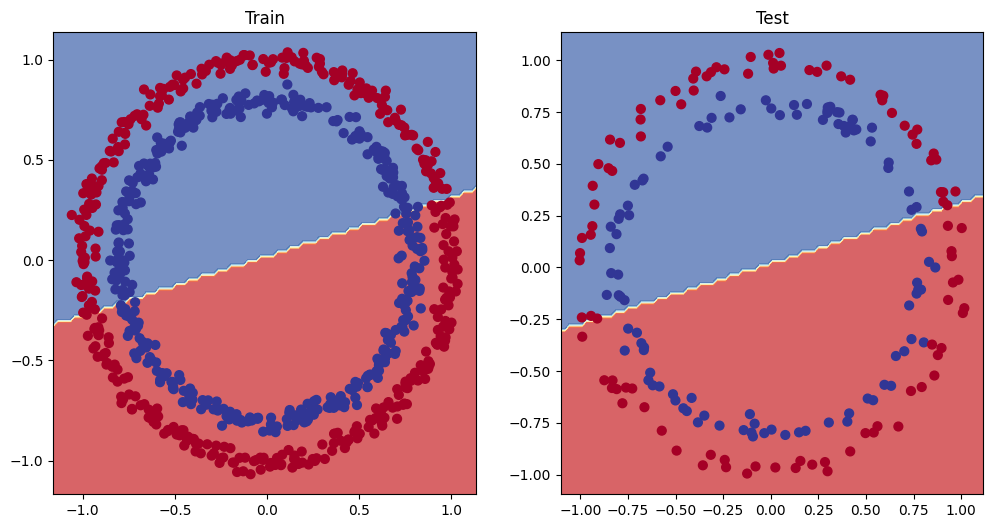

In [30]:
# Plot descision boundy of the model
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (from a model perspective)

* Add more layers - more chance to larn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10
* Fit for longer
* Change the activation function
* Changing the learning rate
* Change the loss function

And because these options are all values we( as ML engineers and data scientists) can change, they are called `hyperparameters`

In [31]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    # adding an additional layer and increasing hidden units 5 -> 10
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

In [32]:
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [33]:
# loss function
loss_fn_v1 = nn.BCEWithLogitsLoss()

# Optimizer
optimizer_v1 = torch.optim.SGD(params = model_1.parameters(),
                               lr = 0.1)

In [34]:
# training model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# epochs 100 -> 1000
epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probs -> pred labels

  loss = loss_fn_v1(y_logits, y_train)
  acc = acc_fn(y_true = y_train, y_pred = y_pred)

  optimizer_v1.zero_grad()

  loss.backward()

  optimizer_v1.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn_v1(test_logits, y_test)
    test_acc = acc_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test Loss: 0.69261 | Test Acc: 51.00%
Epoch: 100 | Loss: 0.69305 | Acc: 50.38% | Test Loss: 0.69379 | Test Acc: 48.00%
Epoch: 200 | Loss: 0.69299 | Acc: 51.12% | Test Loss: 0.69437 | Test Acc: 46.00%
Epoch: 300 | Loss: 0.69298 | Acc: 51.62% | Test Loss: 0.69458 | Test Acc: 45.00%
Epoch: 400 | Loss: 0.69298 | Acc: 51.12% | Test Loss: 0.69465 | Test Acc: 46.00%
Epoch: 500 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69467 | Test Acc: 46.00%
Epoch: 600 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test Acc: 46.00%
Epoch: 700 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test Acc: 46.00%
Epoch: 800 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test Acc: 46.00%
Epoch: 900 | Loss: 0.69298 | Acc: 51.00% | Test Loss: 0.69468 | Test Acc: 46.00%


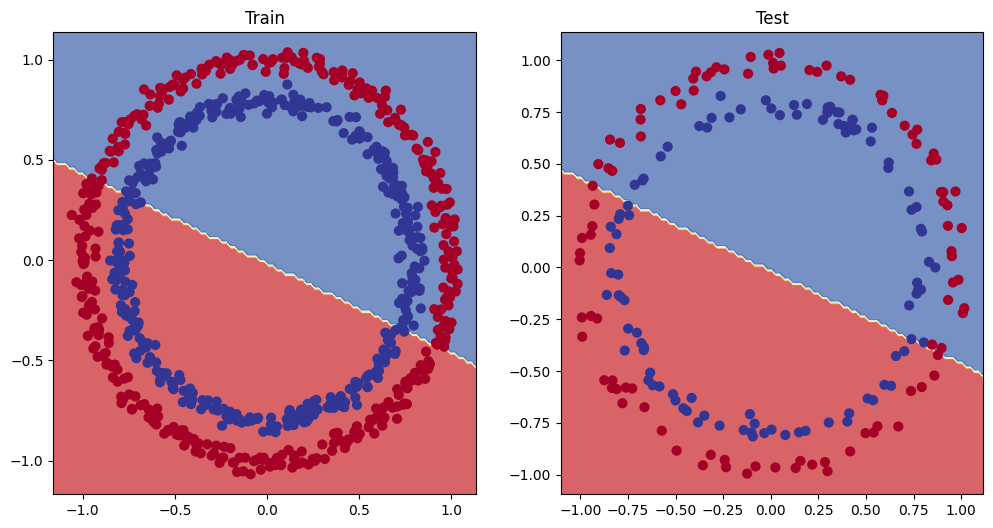

In [35]:
# Plot descision boundy of the model
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot a larger problem is to test out a smaller problem

In [36]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step =0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim = 1)
y_regression = weight * X_regression + bias
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [37]:
# create train and test split
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]
len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

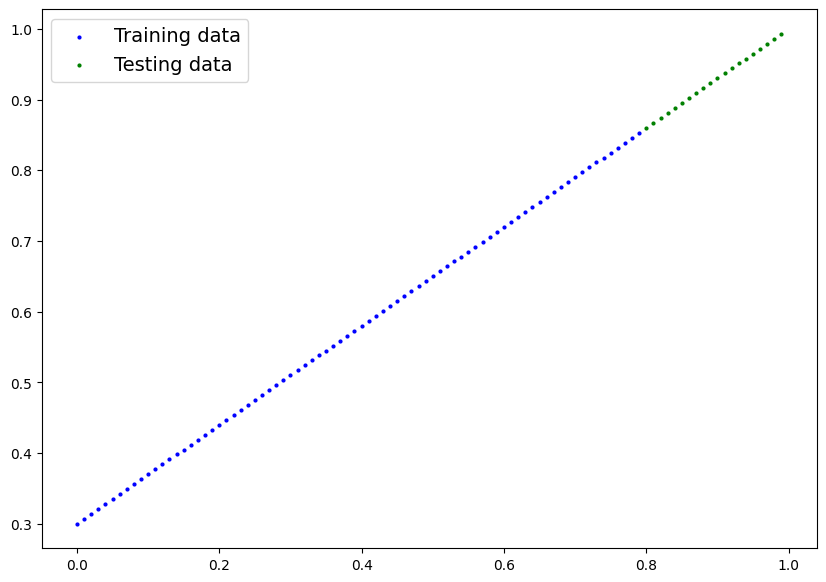

In [38]:
plot_predictions(train_data = X_train_regression,
                 train_labels = y_train_regression,
                 test_data = X_test_regression,
                 test_labels = y_test_regression);

### 5.2 Adjusting  `model_1`to fit a straight line

In [39]:
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10,),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [40]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                               lr = 0.01)

In [41]:
# train a model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):

  y_pred = model_2(X_train_regression)

  loss = loss_fn(y_pred, y_train_regression)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

    if(epoch % 100 == 0):
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


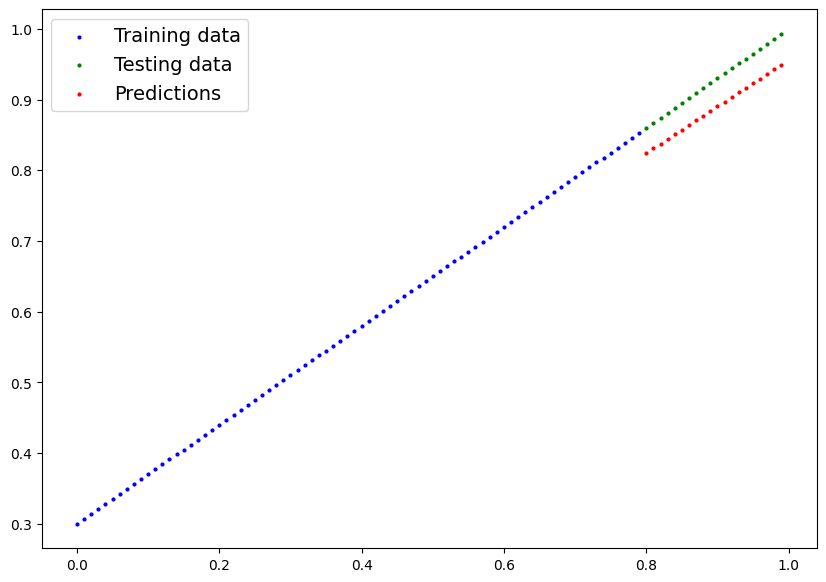

In [42]:
# tURN ON EVAL MMODE
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data = X_train_regression.cpu(),
                 train_labels = y_train_regression.cpu(),
                 test_data = X_test_regression.cpu(),
                 test_labels = y_test_regression.cpu(),
                 predictions = y_preds.cpu())

## 6. The missing piece: non-linearity

### Recreating non-linear data (red and blue circles)

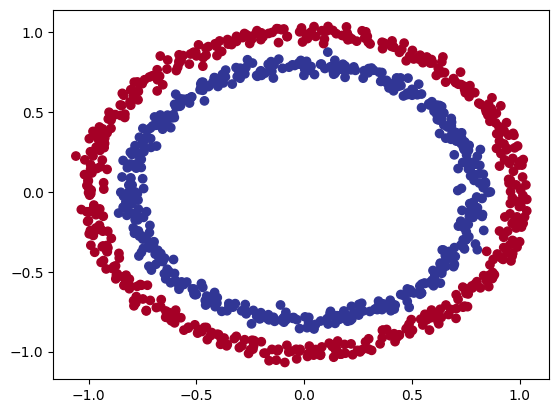

In [43]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                                    noise = 0.03,
                                    random_state = 42
)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.RdYlBu)

In [44]:
# convert data to tensors and then to train ans test split
import torch
from sklearn.model_selection import train_test_split

#Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 building model with non linearity

In [45]:
from torch import nn
class NonLinearModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = NonLinearModelV1().to(device)
model_3

NonLinearModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [46]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.1)

### 6.3 Training a model with non-linearity

In [47]:
#Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

epochs = 1000

for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295 | Acc: 50.00% | Test Loss: 0.69319 | Test Acc: 50.00%
Epoch: 100 | Loss: 0.69115 | Acc: 52.88% | Test Loss: 0.69102 | Test Acc: 52.50%
Epoch: 200 | Loss: 0.68977 | Acc: 53.37% | Test Loss: 0.68940 | Test Acc: 55.00%
Epoch: 300 | Loss: 0.68795 | Acc: 53.00% | Test Loss: 0.68723 | Test Acc: 56.00%
Epoch: 400 | Loss: 0.68517 | Acc: 52.75% | Test Loss: 0.68411 | Test Acc: 56.50%
Epoch: 500 | Loss: 0.68102 | Acc: 52.75% | Test Loss: 0.67941 | Test Acc: 56.50%
Epoch: 600 | Loss: 0.67515 | Acc: 54.50% | Test Loss: 0.67285 | Test Acc: 56.00%
Epoch: 700 | Loss: 0.66659 | Acc: 58.38% | Test Loss: 0.66322 | Test Acc: 59.00%
Epoch: 800 | Loss: 0.65160 | Acc: 64.00% | Test Loss: 0.64757 | Test Acc: 67.50%
Epoch: 900 | Loss: 0.62362 | Acc: 74.00% | Test Loss: 0.62145 | Test Acc: 79.00%


### 6.4 Evaluating a model trained with non linear activation function

In [48]:
model_3.eval()
with torch.inference_mode():
  y_logit = model_3(X_test).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logit))
y_pred[:10], y_test[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

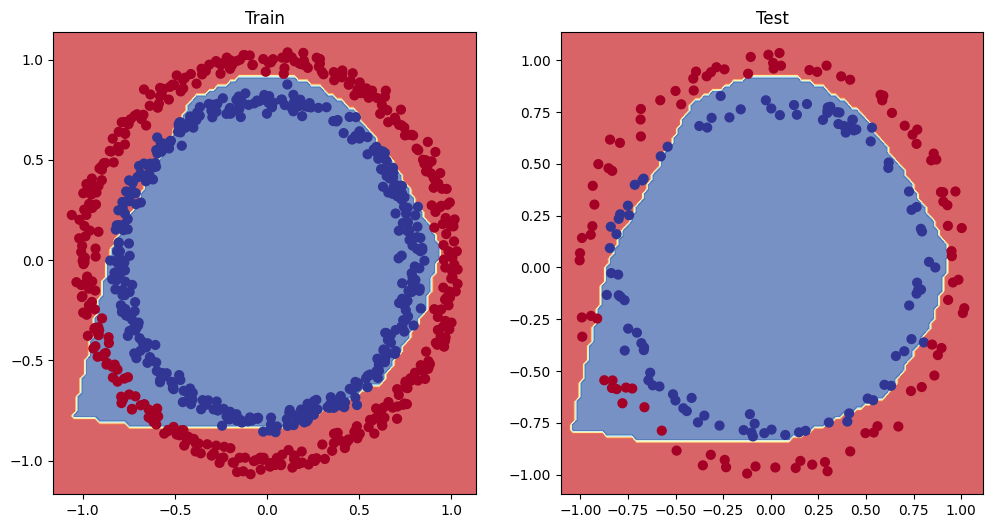

In [49]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

## 7. Replicating non linear activation functions


Neural nets, rather than us telling the model what to learn, we givee it the tools to discover patterns in the data abd it tries to figure out the patterns on ita own

In [50]:
# create a tensor
A = torch.arange(-10, 10, 1, dtype = torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

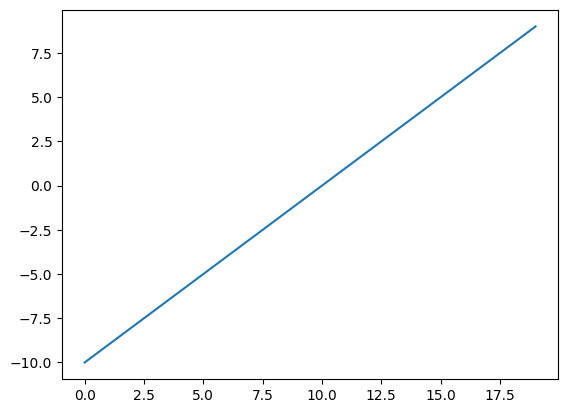

In [52]:
plt.plot(A)

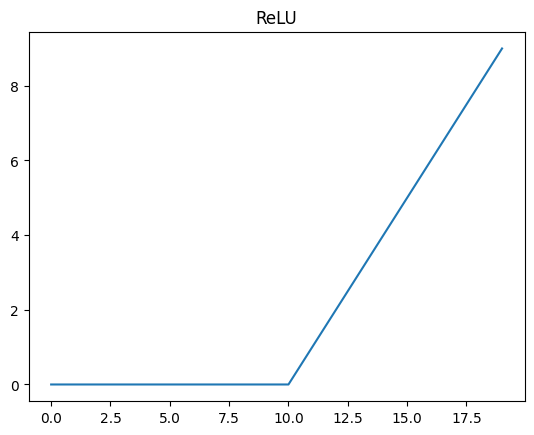

In [53]:
plt.plot(torch.relu(A))
plt.title("ReLU")
plt.show()

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])


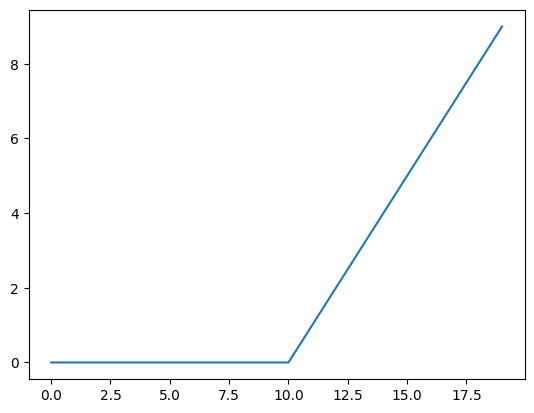

In [61]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x) # inputa can be tensors

print(relu(A))
plt.plot(relu(A))

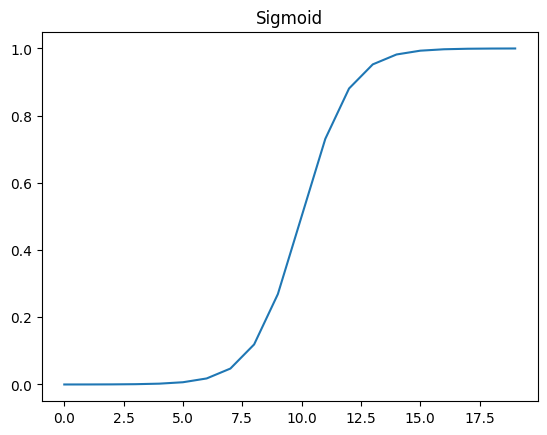

In [51]:
plt.plot(torch.sigmoid(A))
plt.title("Sigmoid")
plt.show()

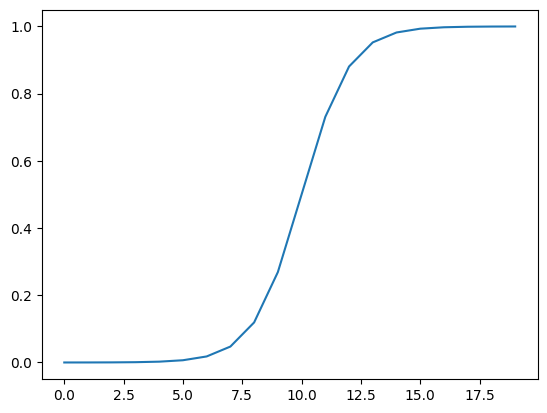

In [60]:
def sigmoid(x):
  return 1/ (1+ torch.exp(-x))

plt.plot(sigmoid(A))

## 8. Putting it all together with a multi class classification problem


### 8.1 Creating a toy multi class dataset

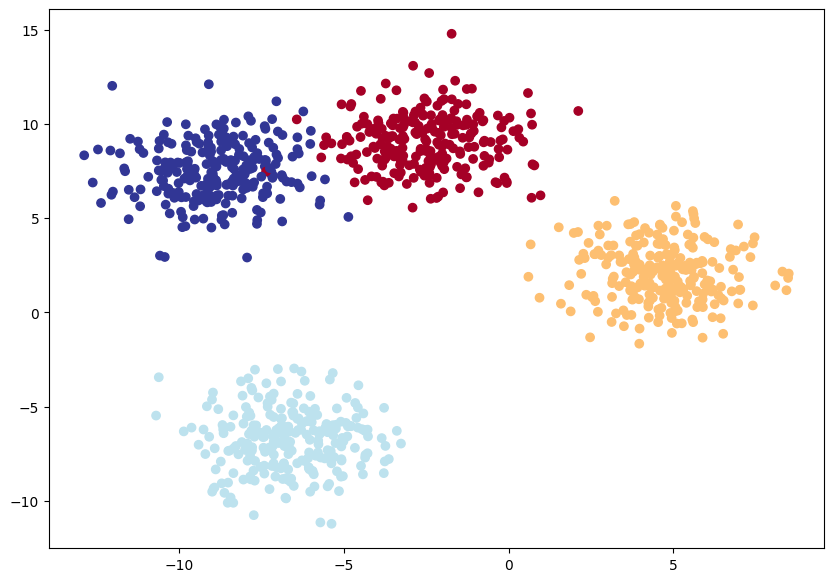

In [67]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# set hyper parameters
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# create data
X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5, # gives cluster a bit of shake up
                            random_state = RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(X_blob,
                                                    y_blob,
                                                    test_size = 0.2,
                                                    random_state = RANDOM_SEED)

plt.figure(figsize = (10, 7))
plt.scatter(X_blob[:,0], X_blob[:, 1], c = y_blob, cmap = plt.cm.RdYlBu)

### 8.2 Building a multi class model in Pytorch

In [105]:
# Create device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [106]:
# build multi class
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 8):
    """Initialize multi-class classification midel.

    Args:
      input_features (int): Number of input features to the model.
      output_features (int): Number of output features of the model.
      hidden_units (int, optional): Size of hidden layers of the model. Defaults to 8.

    Returns:

    """
    super().__init__()
    self.Linear_layer_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = output_features)
    )

  def forward(self, x):
    return self.Linear_layer_stack(x)

model_4 = BlobModel(input_features = 2,
                    output_features = 4).to(device)
model_4

BlobModel(
  (Linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3 Create a loss function and optimizer for multi class problem

In [107]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model_4.parameters(),
                            lr = 0.1)

### 8.4 Getting prediction probabilities for a multi class PyTorch model

In order to evaluate and train and test our model, we need to convert our model's output(logits) to prediciton probabilities and then to prediciton labels.

In [108]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_train.to(device))

y_preds[:10]


tensor([0, 0, 2, 2, 0, 0, 0, 0, 2, 0], device='cuda:0')

In [110]:
y_pred_probs = torch.softmax(y_logits, dim = 1)
print(y_pred_probs[:5])
print(y_logits[:5])

tensor([[0.3080, 0.3328, 0.1441, 0.2150],
        [0.3577, 0.1324, 0.1696, 0.3402],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3000, 0.1845, 0.2743, 0.2413],
        [0.3424, 0.1450, 0.1936, 0.3190]], device='cuda:0')
tensor([[-0.7586, -0.6810, -1.5180, -1.1178],
        [-0.2398, -1.2335, -0.9858, -0.2899],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [ 0.2391, -0.2472,  0.1494,  0.0213],
        [-0.1214, -0.9804, -0.6918, -0.1923]], device='cuda:0')


In [111]:
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0')

In [112]:
torch.max(y_pred_probs[0]), torch.argmax(y_pred_probs[0])

(tensor(0.3328, device='cuda:0'), tensor(1, device='cuda:0'))

In [113]:
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds[:20]

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0],
       device='cuda:0')

In [114]:
y_test[:20]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3],
       device='cuda:0')

### 8.5 Creating a training loop and testing loop for a multi-class PyTorch model

In [115]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_4.train()
  y_logits = model_4(X_train)
  y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_test)
    test_pred = torch.softmax(test_logits, dim = 1).argmax(dim = 1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(y_true = y_test, y_pred = test_pred)
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:2f}%")

Epoch: 0 | Loss: 1.1588 | Acc: 40.38% | Test Loss: 1.0755 | Test Acc: 48.000000%
Epoch: 10 | Loss: 0.6448 | Acc: 96.75% | Test Loss: 0.6607 | Test Acc: 97.500000%
Epoch: 20 | Loss: 0.4254 | Acc: 98.50% | Test Loss: 0.4307 | Test Acc: 100.000000%
Epoch: 30 | Loss: 0.2529 | Acc: 99.12% | Test Loss: 0.2451 | Test Acc: 99.500000%
Epoch: 40 | Loss: 0.1123 | Acc: 99.25% | Test Loss: 0.1023 | Test Acc: 99.500000%
Epoch: 50 | Loss: 0.0663 | Acc: 99.25% | Test Loss: 0.0585 | Test Acc: 99.500000%
Epoch: 60 | Loss: 0.0507 | Acc: 99.25% | Test Loss: 0.0429 | Test Acc: 99.500000%
Epoch: 70 | Loss: 0.0430 | Acc: 99.25% | Test Loss: 0.0349 | Test Acc: 99.500000%
Epoch: 80 | Loss: 0.0384 | Acc: 99.25% | Test Loss: 0.0299 | Test Acc: 99.500000%
Epoch: 90 | Loss: 0.0352 | Acc: 99.25% | Test Loss: 0.0266 | Test Acc: 99.500000%


### 8.6 Making and evaluating predictions with pytorch multi class model

In [116]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_test)
  y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

y_pred[:10], y_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0'),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0'))

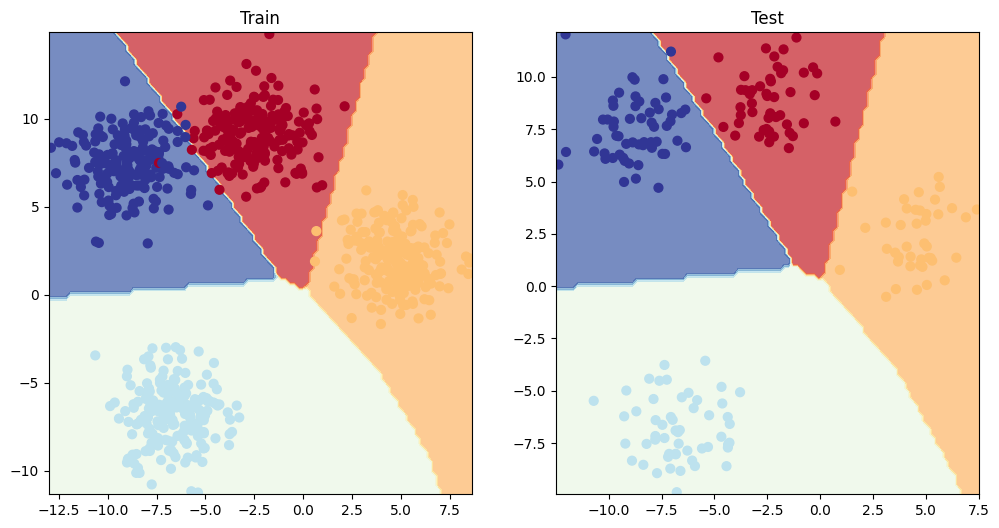

In [118]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_test, y_test)

## 9. Few more classification metrics... (to evaluate our classification model)

* Accuracy
* Precision
* Recall
* F1-Score
* Classification report

https://medium.com/data-science/beyond-accuracy-precision-and-recall-3da06bea9f6c

In [120]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.5 MB/s eta 0:00:00


In [126]:
from torchmetrics import Accuracy as acc
from torchmetrics import Precision as prec
from torchmetrics import Recall as rec
from torchmetrics import F1Score as f1

In [124]:
torchmetrics_acc = acc(task = "multiclass", num_classes = 4).to(device)
torchmetrics_acc(y_pred, y_test)

tensor(0.9950, device='cuda:0')

In [127]:
torchmetrics_prec = prec(task = "multiclass", num_classes = 4).to(device)
torchmetrics_prec(y_pred, y_test)

tensor(0.9950, device='cuda:0')

In [128]:
torchmetrics_f1 = f1(task = "multiclass", num_classes = 4).to(device)
torchmetrics_f1(y_pred, y_test)


tensor(0.9950, device='cuda:0')